# Classical Machine Learning Baseline for Patient Risk Prediction

# ----------------------------
# 0. Import packages here
# ----------------------------

In [1]:
# import the needed packages
import pandas as pd
from sklearn.datasets import make_classification 
# make_classification is used to generate a random n-class classification problem
# This in simple terms means that we can generate a random dataset with a specified number of classes, features, and samples.
# This is great for generating synthetic datasets to test machine learning algorithms.


from sklearn.model_selection import train_test_split
# train_test_split is used to split the dataset into training and testing sets. 
# This is important because we want to train our model on one set of data and test it on another set of data 
# We do this to evaluate model performance on data that was not seen by the model during training.

from sklearn.tree import DecisionTreeClassifier
# DecisionTreeClassifier is a machine learning algorithm that can be used for both classification and regression tasks.
# It works by iteratively breaking the dataset into smaller pieces based on relationships between the features and the target variable.

from sklearn.ensemble import RandomForestClassifier
# Random Forest models work like democracy applied to Decision Trees. 
# Each tree in the forest makes a prediction, and the class with the most votes in the end becomes the model's prediction.
# This leads it to be referred to as "ensemble learning" where multiple models are used to make a prediction.

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# classification_report is used to evaluate the performance of a classification model by providing metrics such as precision, recall, and F1-score for each class.
# confusion_matrix is used to evaluate the performance of a classification model by providing a matrix that shows the number of true positives, true negatives, false positives, and false negatives for each class.
# accuracy_score is used to evaluate the performance by providing the overall accuracy of the model, which is the number of correct predictions divided by the total number of predictions.

import matplotlib.pyplot as plt
# Matplotlib is a data visualization library that provides a wide range of plotting capabilities.

import seaborn as sns
# Seaborn is a data visualization library based on matplotlib that provides very nice graphical representations of data. 

# ----------------------------
# 1. Create synthetic patient-like data
# ----------------------------

In [2]:
X,y= make_classification(
    n_samples=20000, # This is the number of samples we want to generate for the dummy data.
    n_features=12, # This is the number of features we want to generate for the dummy data.
    n_informative=6, # This is the number of "informative features" we want to generate for the dummy data. 
    # Informative features are basically those that are actually useful for predicting the target variable.
    n_redundant=2, # This is the number of redundant features we want to generate for the dummy data. 
    # Redundant features are those that are highly correlated with other features, and hence hold no predictive value.
    n_classes=5, # This is the number of "classes" aka unique groups we want in the dummy data.
    random_state=42 # This is the random state for reproducibility, i.e. if you run this code multiple times, you will get the same results each time.
)

feature_names = [
    "age", "heart_rate", "systolic_bp", "diastolic_bp",
    "spo2", "resp_rate", "glucose", "lactate",
    "creatinine", "hemoglobin", "wbc", "platelets"
]
# feature_names tells us the names of the features in the dataset.

df = pd.DataFrame(X, columns=feature_names) # This just stores our data in a data format.
df["disease_risk"]=y #...while this adds the "classification" column to that dataframe.

classes = df["disease_risk"].unique() # This just gets the unique classes in the dataset.

In [3]:
df.head(10) # This just prints the first couple rows of the dataframe so we can an idea what madness we just created.

,age,heart_rate,systolic_bp,diastolic_bp,spo2,resp_rate,glucose,lactate,creatinine,hemoglobin,wbc,platelets,disease_risk
0,-0.997374,-1.445264,0.494859,-0.799365,2.149282,0.747528,0.750917,-1.804360,1.459794,-0.381958,0.802052,-0.482308,0
1,3.296716,3.071636,-1.254011,-1.031008,-1.809797,2.117675,-0.984634,-1.505780,-1.991836,-0.490332,0.517977,-0.208309,3
2,0.306845,0.559454,0.830793,0.665780,4.063102,0.373564,-1.104323,-2.500481,3.098752,0.630220,1.287933,-0.573542,0
3,-1.659225,-1.343366,-0.428302,-0.100735,0.741445,0.962378,-0.172409,-1.357380,2.181178,-0.395934,-1.632009,1.111931,0
4,-0.071542,-1.030548,1.113612,-0.172948,0.137395,-0.476298,-0.546056,-1.630697,3.172656,-1.279302,-2.225972,0.940137,2
5,2.275366,2.207759,0.116772,-0.631421,1.867053,-1.922715,-0.196845,0.638780,0.765671,0.880665,1.316804,0.686525,4
6,-1.371902,-3.654614,-0.026403,0.136051,3.316025,0.030397,-0.935010,-1.318450,2.137694,-2.318404,0.026515,-0.007233,0
7,1.411509,1.788453,-1.199958,0.563320,-2.408762,1.198638,-1.462551,-5.388603,0.665632,1.548196,3.053898,-1.319448,2
8,-3.296729,-2.134313,-0.610343,0.422685,2.377362,-0.277129,0.157253,-1.904535,5.389498,0.647215,-2.303166,1.357026,0
9,0.330764,-0.718312,1.104481,-0.273241,2.502810,1.319178,-0.249167,-2.143305,0.912501,-1.030770,1.136992,0.022915,0


# ----------------------------
# 2. Re-manage & Split data
# ----------------------------

In [4]:
X = df.drop(columns=["disease_risk"]) # Overwriting the X variable to only contain the features of the dataset.
y = df["disease_risk"] # Overwriting the y variable to only contain the target variable of the dataset.


#Split the data into train and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X,y,
    test_size=0.2, # This is the proportion of the dataset that we want to use for testing.
    random_state=42, # This is the random state for reproducibility.
    stratify=y # This is used to ensure that the distribution of classes in the training and testing sets is similar to that of the original dataset.
    # This ensures that the model is trained on a representative sample distribution.
)

# ----------------------------
# 3. Train Decision Tree
# ----------------------------

In [5]:
dt_model = DecisionTreeClassifier(
    max_depth=10, # This is the maximum depth of the decision tree.
    random_state=42 # This is the random state for reproducibility.
    # NOTE: The documentation contains a bunch of other hyperparameters that we can tune.
)

dt_model.fit(X_train, y_train) # This is where the model is actually trained on the training data.

DecisionTreeClassifier(max_depth=10, random_state=42)

In [6]:
dt_predictions = dt_model.predict(X_test) # This is where the model is used to make predictions on the testing data.
dt_accuracy = accuracy_score(y_test, dt_predictions) # This is where the accuracy of the model is calculated.

### Decision Tree Results

In [7]:
print("Accuracy:", dt_accuracy)

Accuracy: 0.75225


In [8]:
def plot_confusion_matrix(y_test, dt_predictions, classes):
    cm= confusion_matrix(y_test, dt_predictions)
    df_cm = pd.DataFrame(cm, index=classes, columns=classes)

    # 3. Plot with Seaborn
    plt.figure(figsize=(4, 3)) # Set the figure size
    sns.set_theme(style="white") # Set a clean theme

    # 'annot=True' shows the numbers, 'fmt="d"' ensures they are integers
    # 'cmap' can be 'Blues', 'viridis', 'magma', 'rocket', etc.
    sns.heatmap(df_cm,
                annot=True, # This shows the numbers in the heatmap.
                fmt="d", # Alternatively, you can use "f" for floating point numbers.
                cmap="coolwarm", # Alternatively, you can use  "viridis", "magma", etc.
                cbar=True, 
                linewidths=1.5, 
                annot_kws={
                    "size": 16,
                    "weight": "bold"
                    } # This sets the size and weight of the annotations in the heatmap.
                )

    plt.title('Confusion Matrix', fontsize=18, pad=20)
    plt.ylabel('Actual Label', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.show()

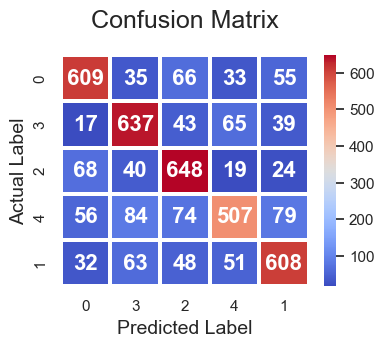

In [9]:
plot_confusion_matrix(y_test, dt_predictions, classes) # This is where the confusion matrix is plotted.

In [10]:
def plot_classification_report(y_test, dt_predictions):
    report_dict=classification_report(y_test,
                                       dt_predictions,
                                       output_dict=True # This makes the output a dictionary instead of a string.
                                       )

    df_report = pd.DataFrame(report_dict).transpose()
    # This just converts the classification report into a dataframe for easier viewing.

    # Apply styling (e.g., color gradient for scores)
    styled_report = df_report.style.background_gradient(
        cmap='RdYlGn',  # Alternatively, you can use 'coolwarm', 'viridis', etc.
        subset=pd.IndexSlice[df_report.index[:-3], ['precision', 'recall', 'f1-score']]
    )
    display(styled_report)


In [11]:
plot_classification_report(y_test, dt_predictions) # This is where the classification report is plotted.

,precision,recall,f1-score,support
0,0.778772,0.763158,0.770886,798.000000
1,0.741560,0.795256,0.767470,801.000000
2,0.737201,0.811014,0.772348,799.000000
3,0.751111,0.633750,0.687458,800.000000
4,0.755280,0.758105,0.756689,802.000000
accuracy,0.752250,0.752250,0.752250,0.752250
macro avg,0.752785,0.752256,0.750970,4000.000000
weighted avg,0.752774,0.752250,0.750962,4000.000000


In [12]:
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": dt_model.feature_importances_,
}).sort_values(by="importance", ascending=False)

print("\nDT Feature Importance")
print(importance_df)


DT Feature Importance
         feature  importance
5      resp_rate    0.183368
4           spo2    0.166818
10           wbc    0.127447
9     hemoglobin    0.123603
1     heart_rate    0.116812
7        lactate    0.100006
0            age    0.099051
8     creatinine    0.065773
3   diastolic_bp    0.005823
11     platelets    0.005247
2    systolic_bp    0.003221
6        glucose    0.002832


# ----------------------------
# 4. Train Random Forest
# ----------------------------

In [13]:
rf_model = RandomForestClassifier(
    n_estimators=200, # This is the number of trees in the forest. More trees usually lead to better performance, but also increase computation time.
    max_depth=8, # This is the maximum depth of each tree. Deeper trees can capture more complex patterns but may lead to overfitting.
    random_state=42 # This ensures reproducibility of the results.
)

rf_model.fit(X_train, y_train) # This is where the model is actually trained on the training data.

RandomForestClassifier(max_depth=8, n_estimators=200, random_state=42)

In [14]:
rf_predictions = rf_model.predict(X_test) # This is where the model is used to make predictions on the testing data.
rf_accuracy = accuracy_score(y_test, rf_predictions) # This is where the accuracy of the model is calculated.

### Random Forest Results

In [15]:
print("Accuracy:", rf_accuracy)

Accuracy: 0.78775


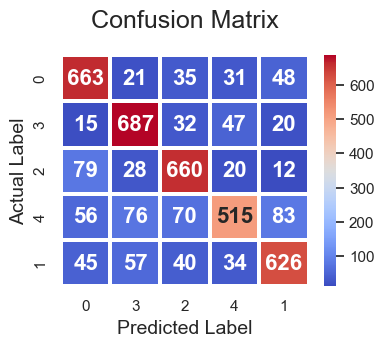

In [16]:
plot_confusion_matrix(y_test, rf_predictions, classes) # This is where the confusion matrix is plotted.

In [17]:
plot_classification_report(y_test, rf_predictions) # This is where the classification report is plotted.

,precision,recall,f1-score,support
0,0.772727,0.830827,0.800725,798.000000
1,0.790564,0.857678,0.822754,801.000000
2,0.788530,0.826033,0.806846,799.000000
3,0.795981,0.643750,0.711818,800.000000
4,0.793409,0.780549,0.786926,802.000000
accuracy,0.787750,0.787750,0.787750,0.787750
macro avg,0.788242,0.787767,0.785814,4000.000000
weighted avg,0.788253,0.787750,0.785811,4000.000000


# ----------------------------
# 5. Feature importance
# ----------------------------

In [18]:
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_,
}).sort_values(by="importance", ascending=False)

print("\nRF Feature Importance")
print(importance_df)


RF Feature Importance
         feature  importance
5      resp_rate    0.158613
1     heart_rate    0.153218
4           spo2    0.142560
9     hemoglobin    0.134609
0            age    0.119270
10           wbc    0.113135
7        lactate    0.083247
8     creatinine    0.080411
2    systolic_bp    0.003946
3   diastolic_bp    0.003775
6        glucose    0.003609
11     platelets    0.003608


# ----------------------------
# 6. Save outputs
# ----------------------------

In [19]:
importance_df.to_csv("results/feature_importance.csv", index=False)

with open("results/model_summary.txt", "w") as f:
    f.write("Classical ML Baseline for Patient Risk Prediction\n")
    f.write("Models compared: Decision Tree and Random Forest\n")
    f.write(f"Decision Tree Accuracy: {dt_accuracy:.4f}\n")
    f.write(f"Random Forest Accuracy: {rf_accuracy:.4f}\n")

print("\nSaved results to the results/ folder.")


Saved results to the results/ folder.
